# **Implementação do algoritmo ACO para o problema do Caixeiro Viajante**
---

**Equipe:** André Felipe, João Kennedy

## **Item A - Versão básica para verificar funcionamento do método**
---

Esta versão usa 5 cidades e serve como base para verificar se o ACO está funcionando corretamente.

### Formulação usada

Cada aresta possui feromônio `tau(i,j)` e visibilidade `eta(i,j) = 1 / distancia(i,j)`. A atratividade de uma cidade candidata é:

`atratividade(i,j) = tau(i,j)^alfa * eta(i,j)^beta`

Na seleção por torneio, algumas cidades ainda não visitadas são sorteadas como candidatas e a cidade com maior atratividade vence o torneio. Depois que todas as formigas constroem suas rotas, o feromônio evapora e cada rota deposita `Q / distancia_da_rota` nas arestas percorridas.

In [90]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [91]:
import random
import time
from dataclasses import dataclass
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [92]:
# grafo completo com 5 cidades
cidades = ["A", "B", "C", "D", "E"]

distancias = np.array(
    [
        [0, 12, 10, 19, 8],
        [12, 0, 3, 7, 6],
        [10, 3, 0, 2, 20],
        [19, 7, 2, 0, 4],
        [8, 6, 20, 4, 0],
    ],
    dtype=float,
)

def imprimir_matriz(matriz, rotulos, casas=2):
    largura = 8
    print("".ljust(largura) + "".join(cidade.rjust(largura) for cidade in rotulos))
    for cidade, linha in zip(rotulos, matriz):
        valores = "".join(f"{valor:.{casas}f}".rjust(largura) for valor in linha)
        print(cidade.ljust(largura) + valores)


imprimir_matriz(distancias, cidades, casas=0)

               A       B       C       D       E
A              0      12      10      19       8
B             12       0       3       7       6
C             10       3       0       2      20
D             19       7       2       0       4
E              8       6      20       4       0


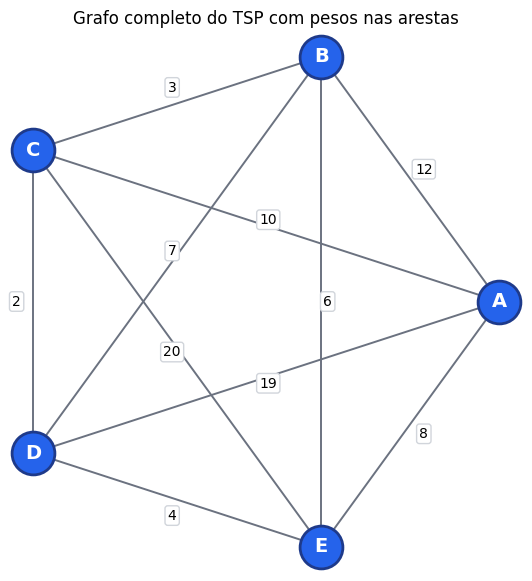

In [93]:
# visualização do grafo com pesos nas arestas
def visualizar_grafo_com_pesos(matriz_distancias, rotulos):
    n_cidades = len(rotulos)
    angulos = np.linspace(0, 2 * np.pi, n_cidades, endpoint=False)
    posicoes = {
        indice: np.array([np.cos(angulo), np.sin(angulo)])
        for indice, angulo in enumerate(angulos)
    }

    fig, ax = plt.subplots(figsize=(7, 7))

    for origem in range(n_cidades):
        for destino in range(origem + 1, n_cidades):
            x1, y1 = posicoes[origem]
            x2, y2 = posicoes[destino]

            ax.plot([x1, x2], [y1, y2], color="#6b7280", linewidth=1.4, zorder=1)

            meio = (posicoes[origem] + posicoes[destino]) / 2
            deslocamento = meio * 0.08
            x_texto, y_texto = meio + deslocamento

            ax.text(
                x_texto,
                y_texto,
                f"{matriz_distancias[origem, destino]:.0f}",
                ha="center",
                va="center",
                fontsize=10,
                bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "edgecolor": "#d1d5db"},
                zorder=3,
            )

    for indice, rotulo in enumerate(rotulos):
        x, y = posicoes[indice]
        ax.scatter(x, y, s=950, color="#2563eb", edgecolor="#1e3a8a", linewidth=2, zorder=4)
        ax.text(x, y, rotulo, ha="center", va="center", color="white", fontsize=14, weight="bold", zorder=5)

    ax.set_title("Grafo completo do TSP com pesos nas arestas")
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()


visualizar_grafo_com_pesos(distancias, cidades)

In [94]:
@dataclass
class ResultadoACO:
    melhor_rota: list[int]
    melhor_distancia: float
    historico_media: list[float]
    historico_melhor_iteracao: list[float]
    feromonios: np.ndarray


def distancia_rota(rota, matriz_distancias):
    total = 0.0
    for origem, destino in zip(rota, rota[1:]):
        total += matriz_distancias[origem, destino]
    total += matriz_distancias[rota[-1], rota[0]]
    return total


def escolher_proxima_cidade_torneio(
    cidade_atual,
    nao_visitadas,
    feromonios,
    matriz_distancias,
    alfa,
    beta,
    tamanho_torneio=3,
):
    quantidade = min(tamanho_torneio, len(nao_visitadas))
    candidatas = random.sample(list(nao_visitadas), quantidade)

    def atratividade(cidade):
        tau = feromonios[cidade_atual, cidade] ** alfa
        eta = (1.0 / matriz_distancias[cidade_atual, cidade]) ** beta
        return tau * eta

    return max(candidatas, key=atratividade)


def construir_rota(
    cidade_inicial,
    feromonios,
    matriz_distancias,
    alfa,
    beta,
    tamanho_torneio=3,
):
    n_cidades = len(matriz_distancias)
    rota = [cidade_inicial]
    nao_visitadas = set(range(n_cidades)) - {cidade_inicial}

    while nao_visitadas:
        proxima = escolher_proxima_cidade_torneio(
            rota[-1],
            nao_visitadas,
            feromonios,
            matriz_distancias,
            alfa,
            beta,
            tamanho_torneio,
        )
        rota.append(proxima)
        nao_visitadas.remove(proxima)

    return rota


def atualizar_feromonios(feromonios, rotas, distancias_rotas, evaporacao, q):
    feromonios *= 1.0 - evaporacao

    for rota, distancia in zip(rotas, distancias_rotas):
        deposito = q / distancia
        rota_fechada = rota + [rota[0]]

        for origem, destino in zip(rota_fechada, rota_fechada[1:]):
            feromonios[origem, destino] += deposito
            feromonios[destino, origem] += deposito

    np.fill_diagonal(feromonios, 0.0)
    return feromonios


def executar_aco(
    matriz_distancias,
    iteracoes=30,
    alfa=1,
    beta=1,
    evaporacao=0.03,
    feromonio_inicial=0.1,
    q=10,
    tamanho_torneio=3
):

    random.seed()
    np.random.seed(None)

    n_cidades = len(matriz_distancias)
    feromonios = np.full((n_cidades, n_cidades), feromonio_inicial, dtype=float)
    np.fill_diagonal(feromonios, 0.0)

    melhor_rota = None
    melhor_distancia = float("inf")
    historico_media = []
    historico_melhor_iteracao = []

    for _ in range(iteracoes):
        rotas = []
        distancias_rotas = []

        # uma formiga começa em cada cidade no ACO
        for cidade_inicial in range(n_cidades):
            rota = construir_rota(
                cidade_inicial,
                feromonios,
                matriz_distancias,
                alfa,
                beta,
                tamanho_torneio,
            )
            distancia = distancia_rota(rota, matriz_distancias)
            rotas.append(rota)
            distancias_rotas.append(distancia)

            if distancia < melhor_distancia:
                melhor_distancia = distancia
                melhor_rota = rota.copy()

        historico_media.append(float(np.mean(distancias_rotas)))
        historico_melhor_iteracao.append(float(np.min(distancias_rotas)))
        feromonios = atualizar_feromonios(
            feromonios,
            rotas,
            distancias_rotas,
            evaporacao,
            q,
        )

    return ResultadoACO(
        melhor_rota=melhor_rota,
        melhor_distancia=melhor_distancia,
        historico_media=historico_media,
        historico_melhor_iteracao=historico_melhor_iteracao,
        feromonios=feromonios,
    )

### Execução da versão básica

In [95]:
resultado = executar_aco(
    distancias,
    iteracoes=30,
    alfa=1,
    beta=1,
    evaporacao=0.03,
    feromonio_inicial=0.1,
    q=10,
    tamanho_torneio=3
)

melhor_rota_nomes = [cidades[i] for i in resultado.melhor_rota] + [cidades[resultado.melhor_rota[0]]]

print("Melhor rota encontrada:", " -> ".join(melhor_rota_nomes))
print(f"Distância da melhor rota: {resultado.melhor_distancia:.2f}")

Melhor rota encontrada: A -> E -> D -> C -> B -> A
Distância da melhor rota: 29.00


In [96]:
historico = []

for iteracao, media, melhor in zip(
    range(1, 31),
    resultado.historico_media,
    resultado.historico_melhor_iteracao,
):
    historico.append(
        {
            "Iteração": iteracao,
            "Média das soluções": media,
            "Melhor solução da iteração": melhor,
        }
    )

print(f"{'Iteração':>8} | {'Média das soluções':>19} | {'Melhor da iteração':>19}")
print("-" * 56)
for linha in historico:
    print(
        f"{linha['Iteração']:>8} | "
        f"{linha['Média das soluções']:>19.2f} | "
        f"{linha['Melhor solução da iteração']:>19.2f}"
    )

Iteração |  Média das soluções |  Melhor da iteração
--------------------------------------------------------
       1 |               32.80 |               29.00
       2 |               33.60 |               29.00
       3 |               32.60 |               29.00
       4 |               33.40 |               29.00
       5 |               30.80 |               29.00
       6 |               29.00 |               29.00
       7 |               29.00 |               29.00
       8 |               29.00 |               29.00
       9 |               29.00 |               29.00
      10 |               29.00 |               29.00
      11 |               29.00 |               29.00
      12 |               29.00 |               29.00
      13 |               29.00 |               29.00
      14 |               29.00 |               29.00
      15 |               29.00 |               29.00
      16 |               29.00 |               29.00
      17 |               29.00 |          

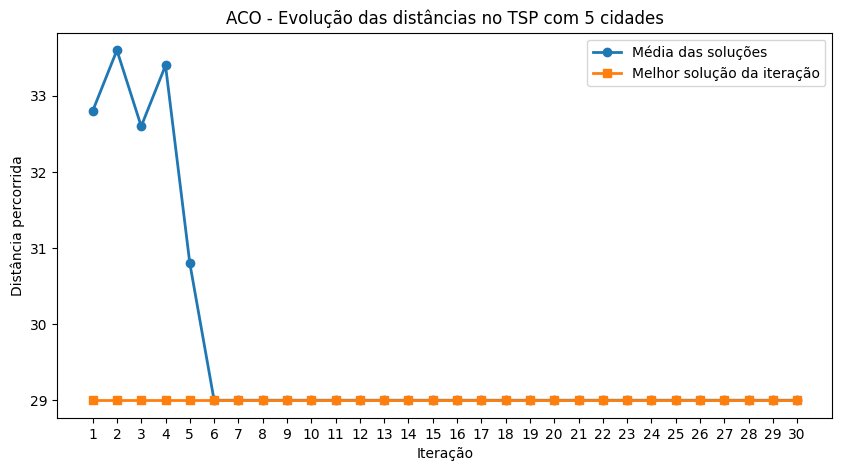

In [97]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    [linha["Iteração"] for linha in historico],
    [linha["Média das soluções"] for linha in historico],
    marker="o",
    linewidth=2,
    label="Média das soluções",
)
ax.plot(
    [linha["Iteração"] for linha in historico],
    [linha["Melhor solução da iteração"] for linha in historico],
    marker="s",
    linewidth=2,
    label="Melhor solução da iteração",
)

ax.set_title("ACO - Evolução das distâncias no TSP com 5 cidades")
ax.set_xlabel("Iteração")
ax.set_ylabel("Distância percorrida")
ax.set_xticks(range(1, 31, 1))
ax.legend()

plt.show()

### **Comentário sobre o funcionamento**

O gráfico e a tabela mostram que o algoritmo encontrou rapidamente uma rota de custo 29.00, considerada a melhor solução observada para a instância com 5 cidades. Após poucas iterações, tanto a média das soluções quanto a melhor solução da iteração permaneceram constantes, indicando convergência total do algoritmo.

Esse comportamento era esperado, pois o problema possui poucas cidades e, consequentemente, um espaço de busca reduzido. Além disso, o método de seleção por torneio favorece escolhas mais determinísticas, acelerando a concentração das formigas em uma mesma rota. O reforço de feromônio nas melhores arestas fez com que as soluções inferiores deixassem de ser escolhidas rapidamente.

In [98]:
# matriz da melhor rota encontrada
def matriz_melhor_rota(rota, matriz_distancias):
    matriz_rota = np.zeros_like(matriz_distancias)
    rota_fechada = rota + [rota[0]]

    for origem, destino in zip(rota_fechada, rota_fechada[1:]):
        matriz_rota[origem, destino] = matriz_distancias[origem, destino]
        matriz_rota[destino, origem] = matriz_distancias[origem, destino]

    return matriz_rota

# visualização da melhor rota encontrada
def visualizar_melhor_rota(rota, matriz_distancias, rotulos, distancia_total=None):
    posicoes = {
        0: np.array([-1.35, 0.00]),  # A
        1: np.array([-0.55, 1.05]),  # B
        2: np.array([-0.10, -1.00]), # C
        3: np.array([0.55, 0.05]),   # D
        4: np.array([1.35, 1.05]),   # E
    }

    rota_fechada = rota + [rota[0]]
    if distancia_total is None:
        distancia_total = distancia_rota(rota, matriz_distancias)

    fig, ax = plt.subplots(figsize=(9, 6))

    for origem, destino in zip(rota_fechada, rota_fechada[1:]):
        p1 = posicoes[origem]
        p2 = posicoes[destino]
        meio = (p1 + p2) / 2
        vetor = p2 - p1
        tamanho = np.linalg.norm(vetor)
        normal = np.array([-vetor[1], vetor[0]]) / tamanho

        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="#16a34a", linewidth=4, zorder=1)

        pos_texto = meio + normal * 0.13
        ax.text(
            pos_texto[0],
            pos_texto[1],
            f"{matriz_distancias[origem, destino]:.0f}",
            color="blue",
            fontsize=24,
            ha="center",
            va="center",
            zorder=3,
        )

    cidade_inicial = rota[0]
    for indice, rotulo in enumerate(rotulos):
        x, y = posicoes[indice]
        cor = "#fb923c" if indice == cidade_inicial else "#2563eb"
        texto = "black" if indice == cidade_inicial else "white"
        ax.scatter(x, y, s=1200, color=cor, edgecolor="#1d4ed8", linewidth=1.5, zorder=4)
        ax.text(x, y, rotulo, ha="center", va="center", color=texto, fontsize=18, zorder=5)

    ax.set_title(f"Melhor rota encontrada pelo ACO\nDistância total: {distancia_total:.2f}")
    ax.set_xlim(-1.75, 1.75)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()

               A       B       C       D       E
A              0      12       0       0       8
B             12       0       3       0       0
C              0       3       0       2       0
D              0       0       2       0       4
E              8       0       0       4       0


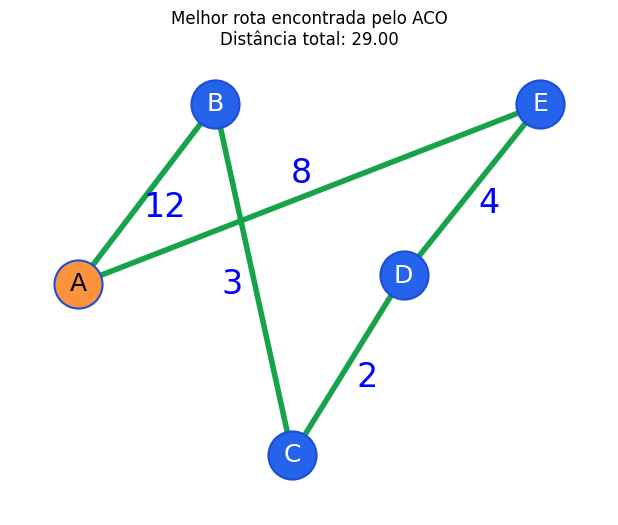

In [99]:
matriz_rota_final = matriz_melhor_rota(resultado.melhor_rota, distancias)
imprimir_matriz(matriz_rota_final, cidades, casas=0)

visualizar_melhor_rota(resultado.melhor_rota, distancias, cidades, resultado.melhor_distancia)


## **B) Verificar a influência dos valores para Alfa e Beta**

Utilizando a versão básica do item A, serão testados os pares `(alfa=0.6, beta=0.2)` e `(alfa=0.2, beta=0.6)`. Os demais parâmetros permanecem iguais aos do item A: 30 iterações, taxa de evaporação 0.03, feromônio inicial 0.1, Q igual a 10 e método de escolha por torneio.

Cada configuração será executada 10 vezes. A comparação usa média, mediana, moda, desvio padrão e boxplot das melhores soluções encontradas.


In [100]:
def calcular_moda(valores):
    valores = list(valores)
    frequencias = {}
    for valor in valores:
        frequencias[valor] = frequencias.get(valor, 0) + 1

    maior_frequencia = max(frequencias.values())
    modas = [valor for valor, freq in frequencias.items() if freq == maior_frequencia]
    return min(modas)


def calcular_estatisticas(valores):
    valores = np.array(valores, dtype=float)
    return {
        "media": float(np.mean(valores)),
        "mediana": float(np.median(valores)),
        "moda": float(calcular_moda(valores)),
        "desvio_padrao": float(np.std(valores, ddof=1)) if len(valores) > 1 else 0.0,
        "minimo": float(np.min(valores)),
        "maximo": float(np.max(valores)),
    }


def imprimir_tabela_estatistica(resultados, nome_parametro):
    print(
        f"{nome_parametro:>18} | {'Média':>8} | {'Mediana':>8} | {'Moda':>8} | "
        f"{'Desvio':>8} | {'Mínimo':>8} | {'Máximo':>8}"
    )
    print("-" * 82)
    for item in resultados:
        estat = item["estatisticas"]
        print(
            f"{item['rotulo']:>18} | "
            f"{estat['media']:>8.2f} | "
            f"{estat['mediana']:>8.2f} | "
            f"{estat['moda']:>8.2f} | "
            f"{estat['desvio_padrao']:>8.2f} | "
            f"{estat['minimo']:>8.2f} | "
            f"{estat['maximo']:>8.2f}"
        )


In [101]:
pares_parametros_b = [
    {"alfa": 0.6, "beta": 0.2},
    {"alfa": 0.2, "beta": 0.6},
]

repeticoes_b = 10
resultados_b = []
historicos_medios_b = {}

for parametros in pares_parametros_b:
    alfa_teste = parametros["alfa"]
    beta_teste = parametros["beta"]
    melhores_distancias = []
    historicos = []
    melhor_rota_parametro = None
    melhor_distancia_parametro = float("inf")

    for _ in range(repeticoes_b):
        resultado_teste = executar_aco(
            distancias,
            iteracoes=30,
            alfa=alfa_teste,
            beta=beta_teste,
            evaporacao=0.03,
            feromonio_inicial=0.1,
            q=10,
            tamanho_torneio=3,
        )

        melhores_distancias.append(resultado_teste.melhor_distancia)
        historicos.append(resultado_teste.historico_media)

        if resultado_teste.melhor_distancia < melhor_distancia_parametro:
            melhor_distancia_parametro = resultado_teste.melhor_distancia
            melhor_rota_parametro = resultado_teste.melhor_rota

    rotulo = f"alfa={alfa_teste}, beta={beta_teste}"
    historicos_medios_b[rotulo] = np.mean(historicos, axis=0)

    resultados_b.append(
        {
            "rotulo": rotulo,
            "alfa": alfa_teste,
            "beta": beta_teste,
            "amostras": melhores_distancias,
            "estatisticas": calcular_estatisticas(melhores_distancias),
            "melhor_rota": melhor_rota_parametro,
        }
    )

resultados_b_ordenados = sorted(
    resultados_b,
    key=lambda item: (
        item["estatisticas"]["media"],
        item["estatisticas"]["mediana"],
        item["estatisticas"]["desvio_padrao"],
    ),
)

melhor_parametro_b = resultados_b_ordenados[0]
melhor_alfa_beta = (melhor_parametro_b["alfa"], melhor_parametro_b["beta"])

print("Comparação dos parâmetros alfa e beta")
print(f"Execuções por configuração: {repeticoes_b}")
print()

imprimir_tabela_estatistica(resultados_b, "Parâmetro")

rota_escolhida_b = [cidades[i] for i in melhor_parametro_b["melhor_rota"]]
rota_escolhida_b.append(rota_escolhida_b[0])

print()
print(f"Melhor par escolhido para o próximo item: alfa={melhor_alfa_beta[0]}, beta={melhor_alfa_beta[1]}")
print("Melhor rota observada com esse par:", " -> ".join(rota_escolhida_b))


Comparação dos parâmetros alfa e beta
Execuções por configuração: 10

         Parâmetro |    Média |  Mediana |     Moda |   Desvio |   Mínimo |   Máximo
----------------------------------------------------------------------------------
alfa=0.6, beta=0.2 |    29.00 |    29.00 |    29.00 |     0.00 |    29.00 |    29.00
alfa=0.2, beta=0.6 |    29.00 |    29.00 |    29.00 |     0.00 |    29.00 |    29.00

Melhor par escolhido para o próximo item: alfa=0.6, beta=0.2
Melhor rota observada com esse par: A -> E -> D -> C -> B -> A


/tmp/ipykernel_20089/2634972823.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


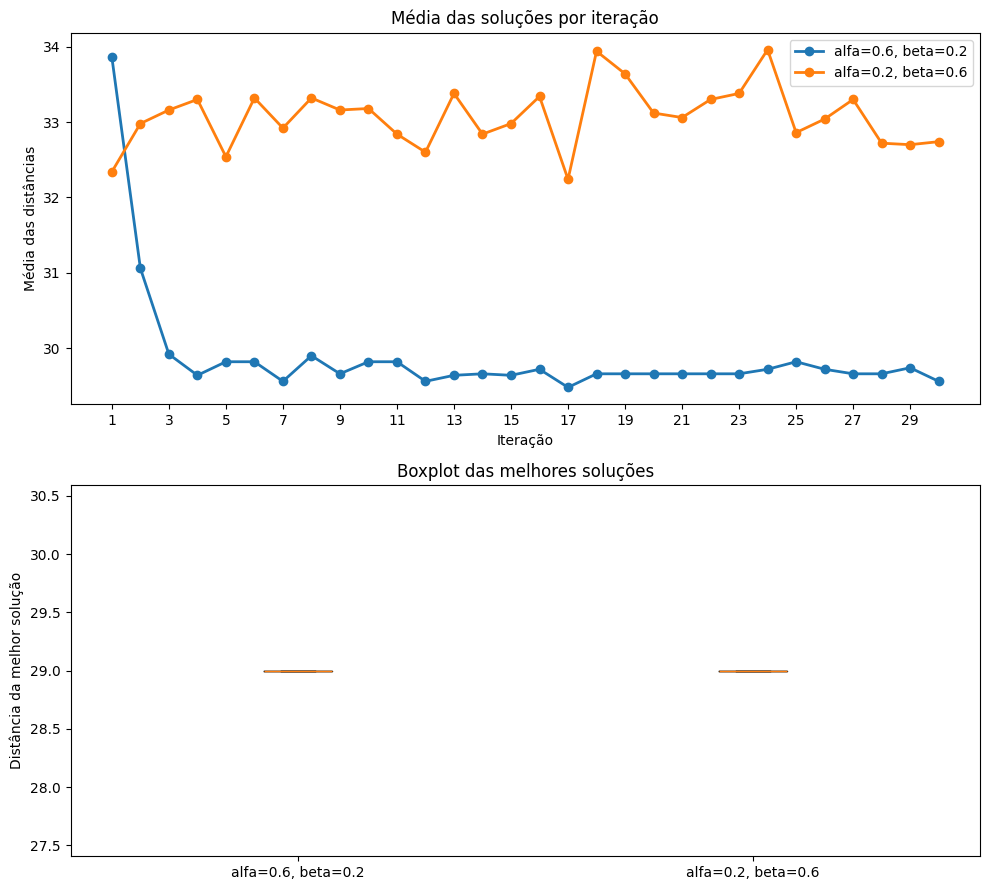

In [102]:
fig, axes = plt.subplots(2, 1, figsize=(10, 9))

for rotulo, historico_medio in historicos_medios_b.items():
    axes[0].plot(
        range(1, 31),
        historico_medio,
        marker="o",
        linewidth=2,
        label=rotulo,
    )

axes[0].set_title("Média das soluções por iteração")
axes[0].set_xlabel("Iteração")
axes[0].set_ylabel("Média das distâncias")
axes[0].set_xticks(range(1, 31, 2))
axes[0].legend()

axes[1].boxplot(
    [item["amostras"] for item in resultados_b],
    labels=[item["rotulo"] for item in resultados_b],
)
axes[1].set_title("Boxplot das melhores soluções")
axes[1].set_ylabel("Distância da melhor solução")

plt.tight_layout()
plt.show()


### Comentário do item B

O par escolhido é definido pela menor média das melhores soluções nas 10 execuções. Em caso de empate, são usados como desempate a mediana e o desvio padrão. Como a instância com 5 cidades é pequena, é comum que os dois pares encontrem a mesma melhor distância; nesse caso, o parâmetro mais interessante é o que apresenta menor dispersão e estabiliza melhor no gráfico das médias. O valor escolhido fica salvo na variável `melhor_alfa_beta`, que será usada no item C.


## **C) Verificar a influência da taxa de evaporação**
---

Nesta etapa são usados os melhores valores de alfa (=0.6) e beta (=0.2) encontrados no item B. Os demais parâmetros continuam iguais ao item A, alterando apenas a taxa de evaporação. Serão testados os valores `0.01`, `0.05`, `0.1` e `0.2`.

Cada taxa será executada 10 vezes, e os resultados serão comparados por média, mediana, moda, desvio padrão e boxplot.


In [103]:
taxas_evaporacao_c = [0.01, 0.05, 0.1, 0.2]
repeticoes_c = 10
resultados_c = []
historicos_medios_c = {}
melhor_alfa_c, melhor_beta_c = melhor_alfa_beta

for evaporacao_teste in taxas_evaporacao_c:
    melhores_distancias = []
    medias_distancias_execucoes = []
    historicos = []
    melhor_rota_taxa = None
    melhor_distancia_taxa = float("inf")

    for _ in range(repeticoes_c):
        resultado_teste = executar_aco(
            distancias,
            iteracoes=30,
            alfa=melhor_alfa_c,
            beta=melhor_beta_c,
            evaporacao=evaporacao_teste,
            feromonio_inicial=0.1,
            q=10,
            tamanho_torneio=3,
        )

        melhores_distancias.append(resultado_teste.melhor_distancia)
        medias_distancias_execucoes.append(float(np.mean(resultado_teste.historico_media)))
        historicos.append(resultado_teste.historico_media)

        if resultado_teste.melhor_distancia < melhor_distancia_taxa:
            melhor_distancia_taxa = resultado_teste.melhor_distancia
            melhor_rota_taxa = resultado_teste.melhor_rota

    rotulo = evaporacao_teste
    historicos_medios_c[rotulo] = np.mean(historicos, axis=0)

    resultados_c.append(
        {
            "rotulo": rotulo,
            "evaporacao": evaporacao_teste,
            "amostras": melhores_distancias,
            "estatisticas": calcular_estatisticas(melhores_distancias),
            "media_distancias": float(np.mean(medias_distancias_execucoes)),
            "melhor_rota": melhor_rota_taxa,
        }
    )

resultados_c_ordenados = sorted(
    resultados_c,
    key=lambda item: (
        item["estatisticas"]["media"],
        item["media_distancias"],
        item["estatisticas"]["mediana"],
        item["estatisticas"]["desvio_padrao"],
    ),
)
melhor_parametro_c = resultados_c_ordenados[0]
melhor_evaporacao = melhor_parametro_c["evaporacao"]

print("Comparação das taxas de evaporação")
print(f"Alfa usado: {melhor_alfa_c}")
print(f"Beta usado: {melhor_beta_c}")
print(f"Execuções por configuração: {repeticoes_c}")
print()
print(
    f"{'Evaporação':>18} | {'Média':>8} | {'Média dist.':>11} | {'Mediana':>8} | "
    f"{'Moda':>8} | {'Desvio':>8} | {'Mínimo':>8} | {'Máximo':>8}"
)
print("-" * 96)
for item in resultados_c:
    estat = item["estatisticas"]
    print(
        f"{item['rotulo']:>18} | "
        f"{estat['media']:>8.2f} | "
        f"{item['media_distancias']:>11.2f} | "
        f"{estat['mediana']:>8.2f} | "
        f"{estat['moda']:>8.2f} | "
        f"{estat['desvio_padrao']:>8.2f} | "
        f"{estat['minimo']:>8.2f} | "
        f"{estat['maximo']:>8.2f}"
    )

rota_escolhida_c = [cidades[i] for i in melhor_parametro_c["melhor_rota"]]
rota_escolhida_c.append(rota_escolhida_c[0])

print()
print(f"Melhor taxa de evaporação escolhida: {melhor_evaporacao}")
print("Melhor rota observada com essa taxa:", " -> ".join(rota_escolhida_c))


Comparação das taxas de evaporação
Alfa usado: 0.6
Beta usado: 0.2
Execuções por configuração: 10

        Evaporação |    Média | Média dist. |  Mediana |     Moda |   Desvio |   Mínimo |   Máximo
------------------------------------------------------------------------------------------------
              0.01 |    29.00 |       29.15 |    29.00 |    29.00 |     0.00 |    29.00 |    29.00
              0.05 |    29.00 |       29.64 |    29.00 |    29.00 |     0.00 |    29.00 |    29.00
               0.1 |    29.00 |       30.23 |    29.00 |    29.00 |     0.00 |    29.00 |    29.00
               0.2 |    29.00 |       29.66 |    29.00 |    29.00 |     0.00 |    29.00 |    29.00

Melhor taxa de evaporação escolhida: 0.01
Melhor rota observada com essa taxa: A -> E -> D -> C -> B -> A


/tmp/ipykernel_20089/41112481.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


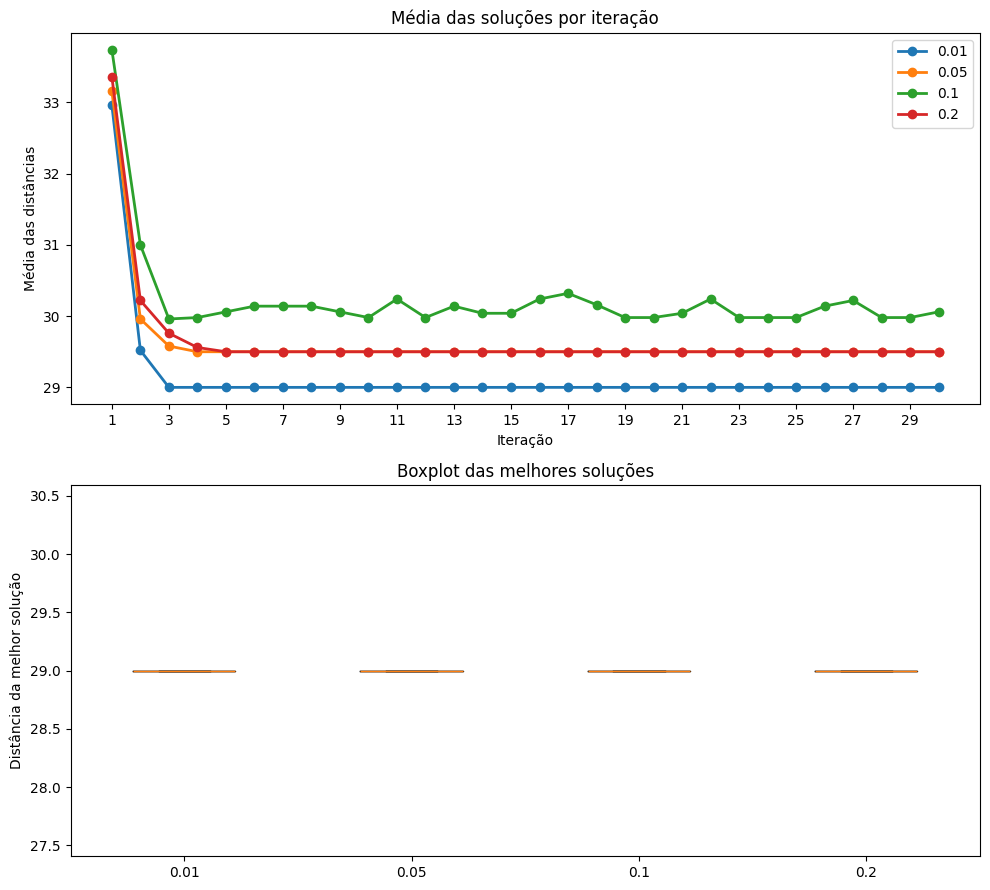

In [104]:
fig, axes = plt.subplots(2, 1, figsize=(10, 9))

for rotulo, historico_medio in historicos_medios_c.items():
    axes[0].plot(
        range(1, 31),
        historico_medio,
        marker="o",
        linewidth=2,
        label=rotulo,
    )

axes[0].set_title("Média das soluções por iteração")
axes[0].set_xlabel("Iteração")
axes[0].set_ylabel("Média das distâncias")
axes[0].set_xticks(range(1, 31, 2))
axes[0].legend()

axes[1].boxplot(
    [item["amostras"] for item in resultados_c],
    labels=[item["rotulo"] for item in resultados_c],
)
axes[1].set_title("Boxplot das melhores soluções")
axes[1].set_ylabel("Distância da melhor solução")

plt.tight_layout()
plt.show()


### Comentário do item C

A taxa de evaporação controla a velocidade com que o algoritmo esquece trilhas antigas. Valores muito baixos preservam o feromônio por mais tempo, o que pode acelerar a convergência, mas também pode reduzir a exploração. Valores mais altos aumentam o esquecimento e favorecem a exploração, mas podem dificultar a estabilização em boas rotas.

A taxa escolhida é a que apresenta a menor média das melhores soluções nas 10 execuções. Em caso de empate, são usados a mediana e o desvio padrão como critérios de desempate. O valor escolhido fica salvo em `melhor_evaporacao`.


## Teste final com 10, 20 e 50 cidades

Nesta etapa é usada a versão final do algoritmo, com os parâmetros definidos nos itens B e C. Para cada tamanho de problema são criados grafos completos com pesos definidos a partir de coordenadas de cidades. O algoritmo executa até que a melhor solução não melhore durante `x` iterações consecutivas.

Configuração do teste final:

- Cidades: 10, 20 e 50
- Execuções por tamanho: 10
- Critério de parada: `x = 50` iterações sem melhoria
- Limite de segurança: 500 iterações
- Métricas: média, mediana, moda, desvio padrão, menor e maior solução, tempo médio e número médio de iterações


In [105]:
def criar_grafo_completo_por_coordenadas(n_cidades, semente=123):
    rng = np.random.default_rng(semente)
    coordenadas = rng.integers(0, 100, size=(n_cidades, 2))
    matriz = np.zeros((n_cidades, n_cidades), dtype=float)

    for i in range(n_cidades):
        for j in range(i + 1, n_cidades):
            distancia = np.linalg.norm(coordenadas[i] - coordenadas[j])
            peso = int(round(distancia)) + 1
            matriz[i, j] = peso
            matriz[j, i] = peso

    rotulos = [f"C{i + 1}" for i in range(n_cidades)]
    return matriz, rotulos, coordenadas


def executar_aco_ate_estagnar(
    matriz_distancias,
    alfa,
    beta,
    evaporacao,
    feromonio_inicial=0.1,
    q=10,
    tamanho_torneio=3,
    limite_sem_melhoria=50,
    max_iteracoes=500,
):
    n_cidades = len(matriz_distancias)
    feromonios = np.full((n_cidades, n_cidades), feromonio_inicial, dtype=float)
    np.fill_diagonal(feromonios, 0.0)

    melhor_rota = None
    melhor_distancia = float("inf")
    historico_media = []
    historico_melhor_iteracao = []
    iteracoes_sem_melhoria = 0
    iteracao = 0
    inicio = time.perf_counter()

    while iteracao < max_iteracoes and iteracoes_sem_melhoria < limite_sem_melhoria:
        iteracao += 1
        rotas = []
        distancias_rotas = []
        houve_melhoria = False

        for cidade_inicial in range(n_cidades):
            rota = construir_rota(
                cidade_inicial,
                feromonios,
                matriz_distancias,
                alfa,
                beta,
                tamanho_torneio,
            )
            distancia = distancia_rota(rota, matriz_distancias)
            rotas.append(rota)
            distancias_rotas.append(distancia)

            if distancia < melhor_distancia:
                melhor_distancia = distancia
                melhor_rota = rota.copy()
                houve_melhoria = True

        historico_media.append(float(np.mean(distancias_rotas)))
        historico_melhor_iteracao.append(float(np.min(distancias_rotas)))
        feromonios = atualizar_feromonios(feromonios, rotas, distancias_rotas, evaporacao, q)

        if houve_melhoria:
            iteracoes_sem_melhoria = 0
        else:
            iteracoes_sem_melhoria += 1

    tempo_execucao = time.perf_counter() - inicio

    return {
        "melhor_rota": melhor_rota,
        "melhor_distancia": melhor_distancia,
        "iteracoes": iteracao,
        "tempo": tempo_execucao,
        "historico_media": historico_media,
        "historico_melhor_iteracao": historico_melhor_iteracao,
    }


In [106]:
tamanhos_final = [10, 20, 50]
repeticoes_final = 10
limite_sem_melhoria = 50
max_iteracoes = 500
resultados_final = []
amostras_boxplot_final = []

for n_cidades in tamanhos_final:
    matriz_teste, rotulos_teste, _ = criar_grafo_completo_por_coordenadas(n_cidades, semente=n_cidades)
    melhores_distancias = []
    tempos = []
    iteracoes = []

    for _ in range(repeticoes_final):
        resultado_teste = executar_aco_ate_estagnar(
            matriz_teste,
            alfa=melhor_alfa_beta[0],
            beta=melhor_alfa_beta[1],
            evaporacao=melhor_evaporacao,
            feromonio_inicial=0.1,
            q=10,
            tamanho_torneio=3,
            limite_sem_melhoria=limite_sem_melhoria,
            max_iteracoes=max_iteracoes,
        )

        melhores_distancias.append(resultado_teste["melhor_distancia"])
        tempos.append(resultado_teste["tempo"])
        iteracoes.append(resultado_teste["iteracoes"])

    estatisticas = calcular_estatisticas(melhores_distancias)
    resultados_final.append(
        {
            "rotulo": f"{n_cidades} cidades",
            "n_cidades": n_cidades,
            "amostras": melhores_distancias,
            "estatisticas": estatisticas,
            "tempo_medio": float(np.mean(tempos)),
            "tempo_desvio": float(np.std(tempos, ddof=1)) if len(tempos) > 1 else 0.0,
            "iteracoes_media": float(np.mean(iteracoes)),
        }
    )
    amostras_boxplot_final.append(melhores_distancias)

print("Teste final com parada por estagnação")
print(f"Alfa: {melhor_alfa_beta[0]}")
print(f"Beta: {melhor_alfa_beta[1]}")
print(f"Evaporação: {melhor_evaporacao}")
print(f"Execuções por tamanho: {repeticoes_final}")
print(f"Parada: {limite_sem_melhoria} iterações sem melhoria")
print()
print(
    f"{'Problema':>12} | {'Média':>8} | {'Mediana':>8} | {'Moda':>8} | "
    f"{'Desvio':>8} | {'Mínimo':>8} | {'Máximo':>8} | {'Tempo médio (s)':>15} | {'Iter. média':>11}"
)
print("-" * 116)
for item in resultados_final:
    estat = item["estatisticas"]
    print(
        f"{item['rotulo']:>12} | "
        f"{estat['media']:>8.2f} | "
        f"{estat['mediana']:>8.2f} | "
        f"{estat['moda']:>8.2f} | "
        f"{estat['desvio_padrao']:>8.2f} | "
        f"{estat['minimo']:>8.2f} | "
        f"{estat['maximo']:>8.2f} | "
        f"{item['tempo_medio']:>15.4f} | "
        f"{item['iteracoes_media']:>11.2f}"
    )


Teste final com parada por estagnação
Alfa: 0.6
Beta: 0.2
Evaporação: 0.01
Execuções por tamanho: 10
Parada: 50 iterações sem melhoria

    Problema |    Média |  Mediana |     Moda |   Desvio |   Mínimo |   Máximo | Tempo médio (s) | Iter. média
--------------------------------------------------------------------------------------------------------------------
  10 cidades |   281.00 |   281.00 |   281.00 |     0.00 |   281.00 |   281.00 |          0.0374 |       59.50
  20 cidades |   514.80 |   519.00 |   519.00 |    30.20 |   441.00 |   549.00 |          0.1775 |       88.50
  50 cidades |  1388.10 |  1399.00 |  1314.00 |    40.11 |  1314.00 |  1433.00 |          1.1235 |       85.50


/tmp/ipykernel_20089/587885072.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


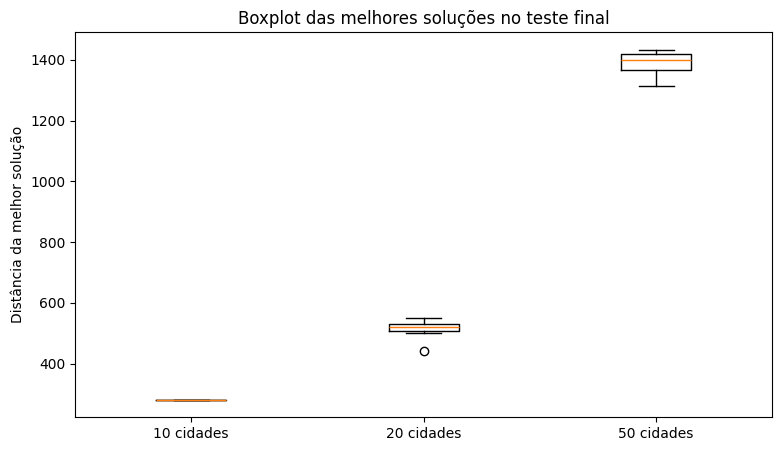

In [107]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(
    amostras_boxplot_final,
    labels=[item["rotulo"] for item in resultados_final],
)
ax.set_title("Boxplot das melhores soluções no teste final")
ax.set_ylabel("Distância da melhor solução")
plt.show()


### Comentário do teste final

O teste final executa o ACO com os parâmetros escolhidos nos itens B e C em instâncias maiores. O critério de parada por estagnação evita fixar previamente uma quantidade única de iterações: o algoritmo continua até que a melhor solução encontrada não mude durante 50 iterações consecutivas, respeitando o limite máximo de 500 iterações.